In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
from scipy import stats
import mne
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
import seaborn as sns
from scipy.spatial.distance import squareform
from scipy.stats import ttest_ind
import os

In [2]:
def analyze_morlets_structure(loaded):
    power_example = loaded['power_0']
    
    print(f"Shape of power data: {power_example.shape}")
    print(f"Number of dimensions: {power_example.ndim}")
    
    if power_example.ndim == 2:
        if power_example.shape[0] == 64 or power_example.shape[0] == 63:
            n_channels = power_example.shape[0]
            n_freq_bins = power_example.shape[1]
            data_structure = "(channels, frequencies)"
        else:
            n_channels = 1
            n_freq_bins = power_example.shape[1]
            data_structure = "(time, frequencies) - single channel"
    
    elif power_example.ndim == 3:
        n_channels = power_example.shape[0]
        n_time_points = power_example.shape[1]
        n_freq_bins = power_example.shape[2]
        data_structure = "(channels, time, frequencies)"
    
    else:
        raise ValueError(f"Unexpected data dimension: {power_example.ndim}")
    
    print(f"Data structure: {data_structure}")
    print(f"Number of channels: {n_channels}")
    print(f"Number of frequency bins: {n_freq_bins}")
    
    freqs = np.linspace(2, 40, n_freq_bins)
    
    return freqs, n_channels, n_freq_bins

In [3]:
def extract_spectral_features(power_data, freqs, data_dims):
    """
    Извлекает спектральные признаки из данных мощности
    
    Возвращает:
    - full_spectrum: полный спектр (усредненный по времени если есть временная размерность)
    """
    if data_dims == '3d':
        # (channels, time, frequencies) -> усредняем по времени
        spectrum = np.mean(power_data, axis=1)  # (channels, frequencies)
    elif data_dims == '2d_temporal':
        # (time, frequencies) -> усредняем по времени
        spectrum = np.mean(power_data, axis=0, keepdims=True)  # (1, frequencies)
    elif data_dims == '2d_spectral':
        # (channels, frequencies) - уже спектральные данные
        spectrum = power_data
    else:
        raise ValueError(f"Unsupported data dimensions: {data_dims}")
    
    return spectrum

In [4]:
def compute_correlation_matrix_optimized(spectra_list, method='pearson'):
    """
    spectra_list: список спектров (любой формы), каждый будет превращён в 1D-вектор
    method: 'pearson' или 'spearman'
    """
    if len(spectra_list) == 0:
        raise ValueError("spectra_list is empty")

    # 1) flatten -> 1D
    flat = [np.asarray(spec).ravel() for spec in spectra_list]

    # 2) привести к одинаковой длине (иначе np.array не соберётся)
    min_len = min(v.size for v in flat)
    if min_len == 0:
        raise ValueError("At least one spectrum is empty (size=0)")

    flat = [v[:min_len] for v in flat]  # crop to min length

    # 3) (n_spectra, n_features)
    X = np.stack(flat, axis=0).astype(np.float32)

    # 4) Spearman = Pearson по рангам
    if method.lower() == 'spearman':
        # ranks per row (простая реализация через argsort(argsort))
        # ties будут обработаны грубо (без усреднения рангов), но часто этого достаточно
        order = np.argsort(X, axis=1)
        ranks = np.empty_like(order, dtype=np.float32)
        rows = np.arange(X.shape[0])[:, None]
        ranks[rows, order] = np.arange(X.shape[1], dtype=np.float32)[None, :]
        X = ranks
    elif method.lower() != 'pearson':
        raise ValueError("method must be 'pearson' or 'spearman'")

    # 5) Pearson через cosine similarity после центрирования
    X = X - X.mean(axis=1, keepdims=True)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    Xn = X / norms

    corr_matrix = Xn @ Xn.T
    return corr_matrix


In [5]:
def collect_intra_inter_correlations_optimized(corr_matrix, subject_ids):
    """
    Собирает внутри- и межсубъектные корреляции с оптимизацией памяти
    """
    n_sessions = len(subject_ids)
    intra_corrs = []
    inter_corrs = []
    
    # Используем более эффективный подход для больших матриц
    unique_subjects = np.unique(subject_ids)
    
    # Сначала собираем внутрисубъектные корреляции
    for subj in unique_subjects:
        # Находим индексы сессий этого субъекта
        subj_indices = np.where(subject_ids == subj)[0]
        n_subj_sessions = len(subj_indices)
        
        if n_subj_sessions >= 2:
            # Для каждой пары сессий внутри субъекта
            for i in range(n_subj_sessions):
                idx_i = subj_indices[i]
                for j in range(i + 1, n_subj_sessions):
                    idx_j = subj_indices[j]
                    intra_corrs.append(corr_matrix[idx_i, idx_j])
    
    # Затем собираем межсубъектные корреляции
    for i in range(n_sessions):
        for j in range(i + 1, n_sessions):
            if subject_ids[i] != subject_ids[j]:
                inter_corrs.append(corr_matrix[i, j])
    
    return np.array(intra_corrs), np.array(inter_corrs)

In [6]:
def perform_statistical_tests_optimized(intra_corrs, inter_corrs, n_permutations=1000):
    """
    Оптимизированная версия статистических тестов
    """
    results = {}
    
    # Проверка на наличие данных
    if len(intra_corrs) == 0 or len(inter_corrs) == 0:
        print("Warning: Not enough data for statistical tests")
        return results
    
    # 1. Welch t-test (предполагает нормальность распределений)
    t_stat, t_p_value = ttest_ind(intra_corrs, inter_corrs, equal_var=False)
    results['t_test'] = {
        'statistic': t_stat,
        'p_value': t_p_value,
        'mean_intra': np.mean(intra_corrs),
        'mean_inter': np.mean(inter_corrs),
        'std_intra': np.std(intra_corrs, ddof=1),
        'std_inter': np.std(inter_corrs, ddof=1),
        'n_intra': len(intra_corrs),
        'n_inter': len(inter_corrs)
    }
    
    # 2. Мануальный permutation test с экономией памяти
    print(f"  Performing manual permutation test ({n_permutations} permutations)...")
    
    # Объединяем все корреляции
    all_corrs = np.concatenate([intra_corrs, inter_corrs])
    n_intra = len(intra_corrs)
    n_total = len(all_corrs)
    
    # Наблюдаемая статистика
    observed_stat = np.mean(intra_corrs) - np.mean(inter_corrs)
    
    # Генерируем перестановки
    permutation_stats = np.zeros(n_permutations)
    
    for i in tqdm(range(n_permutations), desc="Permutation test"):
        # Перемешиваем метки
        permuted_indices = np.random.permutation(n_total)
        
        # Разделяем на две "псевдо-группы"
        perm_group1 = all_corrs[permuted_indices[:n_intra]]
        perm_group2 = all_corrs[permuted_indices[n_intra:]]
        
        # Вычисляем статистику для перестановки
        permutation_stats[i] = np.mean(perm_group1) - np.mean(perm_group2)
    
    # Вычисляем p-value
    p_value_perm = np.sum(permutation_stats >= observed_stat) / n_permutations
    
    results['permutation_test'] = {
        'statistic': observed_stat,
        'p_value': p_value_perm,
        'n_permutations': n_permutations
    }
    
    # 3. Cohen's d для размера эффекта
    pooled_std = np.sqrt((np.std(intra_corrs, ddof=1)**2 + np.std(inter_corrs, ddof=1)**2) / 2)
    cohens_d = (np.mean(intra_corrs) - np.mean(inter_corrs)) / pooled_std if pooled_std > 0 else 0
    
    results['effect_size'] = {
        'cohens_d': cohens_d,
        'pooled_std': pooled_std
    }
    
    # 4. Дополнительные описательные статистики
    results['descriptive'] = {
        'median_intra': np.median(intra_corrs),
        'median_inter': np.median(inter_corrs),
        'q25_intra': np.percentile(intra_corrs, 25),
        'q75_intra': np.percentile(intra_corrs, 75),
        'q25_inter': np.percentile(inter_corrs, 25),
        'q75_inter': np.percentile(inter_corrs, 75),
        'min_intra': np.min(intra_corrs),
        'max_intra': np.max(intra_corrs),
        'min_inter': np.min(inter_corrs),
        'max_inter': np.max(inter_corrs)
    }
    
    return results

In [7]:
def create_topomap_plots(spectra_list, subject_ids, freqs, n_channels=63):
    """
    Создает топомапы для внутрисубъектных и межсубъектных различий
    
    Args:
        spectra_list: список спектров (n_channels, n_frequencies, time_points)
        subject_ids: идентификаторы субъектов
        freqs: частоты (должны соответствовать time_points)
        n_channels: количество каналов
    """
    print("\nCreating topomap visualizations...")
    
    # Проверяем, есть ли многоканальные данные
    if len(spectra_list) == 0 or spectra_list[0].ndim != 3:
        print("  Warning: No 3D multi-channel data available for topomaps")
        return
    
    # Получаем актуальную длину времени из первого спектра
    time_points = spectra_list[0].shape[2]  # должно быть 309 после обрезки
    
    # Проверяем соответствие частот и временных точек
    if len(freqs) != time_points:
        print(f"  Warning: freq array has {len(freqs)} points, but spectra have {time_points} time points")
        print(f"  Truncating freqs array to match spectra...")
        freqs = freqs[:time_points]  # Обрезаем до правильной длины
    
    # Определяем частотные диапазоны
    freq_bands = {
        'Delta (1-4 Hz)': (1, 4),
        'Theta (4-8 Hz)': (4, 7),
        'Alpha (8-13 Hz)': (8, 13),
        'Beta (13-30 Hz)': (14, 30)
    }
    
    # Создаем фигуру для топомапов
    n_bands = len(freq_bands)
    fig, axes = plt.subplots(3, n_bands, figsize=(4*n_bands, 10))
    if n_bands == 1:
        axes = axes.reshape(3, 1)
    
    # Создаем упрощенную информацию о каналах для 63-канальной системы
    print("  Creating montage for 63-channel EEG system...")
    
    # Стандартные названия каналов для 63-канальной системы
    # Базовый набор каналов 10-20 системы
    standard_channels = [
        'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FT7', 'FC3', 'FCz', 
        'FC4', 'FT8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP7', 'CP3', 'CPz', 
        'CP4', 'TP8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2', 'Oz'
    ]
    
    # Добавляем дополнительные каналы для 63-канальной системы
    extra_channels = [
        'Fpz', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FC5',
        'FC1', 'FC2', 'FC6', 'C5', 'C1', 'C2', 'C6', 'CP5', 'CP1', 'CP2',
        'CP6', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO3', 'POz', 'PO4', 'PO8',
        'FT9', 'FT10', 'TP9', 'TP10'
    ]
    
    # Объединяем каналы
    ch_names = standard_channels + extra_channels
    # Берем только первые n_channels каналов
    ch_names = ch_names[:n_channels]
    
    # Создаем info
    info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types='eeg')
    
    # Создаем кастомный montage
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        montage_ch_names = list(montage.ch_names)
        ch_pos = {}
        
        # Сопоставляем наши каналы с каналами в montage
        for ch in ch_names:
            if ch in montage_ch_names:
                ch_pos[ch] = montage.get_positions()['ch_pos'][ch]
            else:
                # Для каналов, которых нет в стандартном montage
                print(f"    Warning: Channel {ch} not in standard montage, using approximate position")
                ch_pos[ch] = np.array([0, 0, 0])  # Временная позиция
        
        # Создаем кастомный montage
        montage = mne.channels.make_dig_montage(ch_pos=ch_pos)
        info.set_montage(montage)
        print(f"    Created montage with {len(ch_pos)} channels")
        
    except Exception as e:
        print(f"    Error creating montage: {e}")
        print("    Using spherical layout without specific montage")
    
    # Группируем данные по субъектам
    unique_subjects = np.unique(subject_ids)
    subject_groups = {}
    
    for subj in unique_subjects:
        subject_indices = np.where(subject_ids == subj)[0]
        if len(subject_indices) >= 2:  # Нужно хотя бы 2 сессии для внутрисубъектного анализа
            subject_groups[subj] = [spectra_list[i] for i in subject_indices]
    
    # Для каждого частотного диапазона вычисляем средние различия
    for band_idx, (band_name, (low_freq, high_freq)) in enumerate(freq_bands.items()):
        print(f"  Processing {band_name}...")
        
        # ИСПРАВЛЕНО: Создаем маску для частотного диапазона
        # Используем обрезанный массив freqs
        freq_mask = (freqs >= low_freq) & (freqs < high_freq)
        
        # Проверяем, что маска имеет правильную длину
        if len(freq_mask) != time_points:
            print(f"    Warning: Frequency mask length mismatch: {len(freq_mask)} vs {time_points}")
            # Обрезаем маску до правильной длины
            min_len = min(len(freq_mask), time_points)
            freq_mask = freq_mask[:min_len]
        
        # Проверяем, есть ли какие-то частоты в диапазоне
        if not np.any(freq_mask):
            print(f"    Warning: No frequencies found in range {low_freq}-{high_freq} Hz")
            continue
        
        # Вычисляем внутрисубъектные различия
        intra_diffs = []
        for subj, subj_spectra in subject_groups.items():
            if len(subj_spectra) >= 2:
                # Усредняем по частотам в диапазоне для каждого канала
                band_spectra = []
                for spec in subj_spectra:
                    # Обрезаем маску до длины спектра
                    spec_time_points = spec.shape[2]
                    mask_len = min(len(freq_mask), spec_time_points)
                    # Убеждаемся, что используем правильную часть маски
                    current_freq_mask = freq_mask[:mask_len]
                    
                    if spec.shape[2] != mask_len:
                        # Если спектр короче, обрезаем маску еще больше
                        current_freq_mask = current_freq_mask[:spec.shape[2]]
                    
                    # Усредняем по частотам в диапазоне
                    if np.any(current_freq_mask):
                        band_power = np.mean(spec[:, :, current_freq_mask], axis=(1, 2))
                        band_spectra.append(band_power)
                
                if band_spectra:
                    # Вычисляем стандартное отклонение между сессиями для каждого канала
                    band_array = np.stack(band_spectra, axis=0)  # (n_sessions, n_channels)
                    # Берем только первые n_channels каналов для совместимости с info
                    n_plot_channels = min(band_array.shape[1], len(info['ch_names']))
                    subj_std = np.std(band_array[:, :n_plot_channels], axis=0)
                    intra_diffs.append(subj_std)
        
        # Вычисляем межсубъектные различия
        inter_diffs = []
        subject_means = []
        for subj, subj_spectra in subject_groups.items():
            if len(subj_spectra) >= 1:
                # Усредняем по частотам и по сессиям для каждого субъекта
                subj_band_powers = []
                for spec in subj_spectra:
                    # Обрезаем маску до длины спектра
                    spec_time_points = spec.shape[2]
                    mask_len = min(len(freq_mask), spec_time_points)
                    current_freq_mask = freq_mask[:mask_len]
                    
                    if spec.shape[2] != mask_len:
                        current_freq_mask = current_freq_mask[:spec.shape[2]]
                    
                    if np.any(current_freq_mask):
                        band_power = np.mean(spec[:, :, current_freq_mask], axis=(1, 2))
                        subj_band_powers.append(band_power)
                
                if subj_band_powers:
                    n_plot_channels = min(subj_band_powers[0].shape[0], len(info['ch_names']))
                    # Обрезаем каждый спектр до нужного количества каналов
                    trimmed_powers = [spec[:n_plot_channels] for spec in subj_band_powers]
                    subj_mean = np.mean(np.stack(trimmed_powers, axis=0), axis=0)
                    subject_means.append(subj_mean)
        
        if len(subject_means) >= 2:
            subject_means_array = np.array(subject_means)  # (n_subjects, n_channels)
            n_plot_channels = min(subject_means_array.shape[1], len(info['ch_names']))
            inter_std = np.std(subject_means_array[:, :n_plot_channels], axis=0)
            inter_diffs = inter_std
        else:
            inter_diffs = []
        
        # Преобразуем в массивы для визуализации
        n_plot_channels = len(info['ch_names'])
        
        if intra_diffs:
            intra_array = np.array(intra_diffs)
            # Обрезаем или дополняем до нужного количества каналов
            if intra_array.shape[1] >= n_plot_channels:
                intra_mean = np.mean(intra_array[:, :n_plot_channels], axis=0)
            else:
                intra_mean = np.zeros(n_plot_channels)
                intra_mean[:intra_array.shape[1]] = np.mean(intra_array, axis=0)
        else:
            intra_mean = np.zeros(n_plot_channels)
        
        if len(inter_diffs) > 0:
            if len(inter_diffs) >= n_plot_channels:
                inter_mean = inter_diffs[:n_plot_channels]
            else:
                inter_mean = np.zeros(n_plot_channels)
                inter_mean[:len(inter_diffs)] = inter_diffs
        else:
            inter_mean = np.zeros(n_plot_channels)
        
        # Вычисляем разницу (красный - синий)
        diff_mean = inter_mean - intra_mean
        
        # Функция для симметричных пределов цвета
        def sym_vlim(v):
            vmax = np.nanmax(np.abs(v))
            return (-vmax, vmax) if np.isfinite(vmax) and vmax > 0 else (-1, 1)
        
        # 1. Внутрисубъектные различия (синий)
        ax1 = axes[0, band_idx]
        if np.any(intra_mean != 0):
            try:
                # Используем правильный API для plot_topomap
                im1, _ = mne.viz.plot_topomap(intra_mean, info, axes=ax1, show=False, 
                                             cmap='Blues', contours=0, sensors=True)
                ax1.set_title(f'{band_name}\nIntra-subject\nVariability', fontsize=10)
            except Exception as e:
                print(f"    Error plotting intra-subject topomap: {e}")
                ax1.text(0.5, 0.5, 'Plot error', transform=ax1.transAxes, 
                        ha='center', va='center')
                ax1.set_title(f'{band_name}\nIntra-subject\n(Error)', fontsize=10)
        else:
            ax1.text(0.5, 0.5, 'No data', transform=ax1.transAxes, 
                    ha='center', va='center')
            ax1.set_title(f'{band_name}\nIntra-subject\n(No data)', fontsize=10)
        
        # 2. Межсубъектные различия (красный)
        ax2 = axes[1, band_idx]
        if np.any(inter_mean != 0):
            try:
                im2, _ = mne.viz.plot_topomap(inter_mean, info, axes=ax2, show=False, 
                                             cmap='Reds', contours=0, sensors=True)
                ax2.set_title(f'{band_name}\nInter-subject\nVariability', fontsize=10)
            except Exception as e:
                print(f"    Error plotting inter-subject topomap: {e}")
                ax2.text(0.5, 0.5, 'Plot error', transform=ax2.transAxes, 
                        ha='center', va='center')
                ax2.set_title(f'{band_name}\nInter-subject\n(Error)', fontsize=10)
        else:
            ax2.text(0.5, 0.5, 'No data', transform=ax2.transAxes, 
                    ha='center', va='center')
            ax2.set_title(f'{band_name}\nInter-subject\n(No data)', fontsize=10)
        
        # 3. Разница (красный - синий) с симметричной цветовой шкалой
        ax3 = axes[2, band_idx]
        if np.any(diff_mean != 0):
            try:
                vlim = sym_vlim(diff_mean)
                im3, _ = mne.viz.plot_topomap(diff_mean, info, axes=ax3, show=False, 
                                             cmap='RdBu_r', contours=0, sensors=True)
                ax3.set_title(f'{band_name}\nDifference\n(Inter - Intra)', fontsize=10)
            except Exception as e:
                print(f"    Error plotting difference topomap: {e}")
                ax3.text(0.5, 0.5, 'Plot error', transform=ax3.transAxes, 
                        ha='center', va='center')
                ax3.set_title(f'{band_name}\nDifference\n(Error)', fontsize=10)
        else:
            ax3.text(0.5, 0.5, 'No data', transform=ax3.transAxes, 
                    ha='center', va='center')
            ax3.set_title(f'{band_name}\nDifference\n(No data)', fontsize=10)
    
    # Добавляем заголовки для столбцов
    axes[0, 0].set_ylabel('Intra-subject\n(Blue)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Inter-subject\n(Red)', fontsize=12, fontweight='bold')
    axes[2, 0].set_ylabel('Difference\n(Red-Blue)', fontsize=12, fontweight='bold')
    
    plt.suptitle('Topographic Distribution of Spectral Variability\n'
                'Blue: Intra-subject variability | Red: Inter-subject variability | Difference: Inter - Intra', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

In [8]:
def visualize_results_basic(intra_corrs, inter_corrs, results, subject_ids):
    """
    Базовая визуализация результатов (меньше графиков для экономии памяти)
    """
    fig = plt.figure(figsize=(15, 10))
    
    # 1. Гистограммы распределений корреляций
    ax1 = plt.subplot(2, 2, 1)
    bins = np.linspace(-1, 1, 41)
    ax1.hist(intra_corrs, bins=bins, alpha=0.7, label=f'Intra-subject (n={len(intra_corrs)})', 
             density=True, color='blue')
    ax1.hist(inter_corrs, bins=bins, alpha=0.7, label=f'Inter-subject (n={len(inter_corrs)})', 
             density=True, color='red')
    ax1.set_xlabel('Correlation')
    ax1.set_ylabel('Density')
    ax1.set_title('Distribution of Correlations')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Box plot
    ax2 = plt.subplot(2, 2, 2)
    box_data = [intra_corrs, inter_corrs]
    box_labels = ['Intra-subject', 'Inter-subject']
    bp = ax2.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
    
    # Цвета для box plot
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax2.set_ylabel('Correlation')
    ax2.set_title('Box Plot of Correlations')
    ax2.grid(True, alpha=0.3)
    
    # 3. Violin plot (альтернатива box plot)
    ax3 = plt.subplot(2, 2, 3)
    violin_data = [intra_corrs, inter_corrs]
    violin_parts = ax3.violinplot(violin_data, showmeans=True, showmedians=True)
    
    # Цвета для violin plot
    for i, pc in enumerate(violin_parts['bodies']):
        if i == 0:
            pc.set_facecolor('blue')
            pc.set_alpha(0.7)
        else:
            pc.set_facecolor('red')
            pc.set_alpha(0.7)
    
    ax3.set_xticks([1, 2])
    ax3.set_xticklabels(['Intra-subject', 'Inter-subject'])
    ax3.set_ylabel('Correlation')
    ax3.set_title('Violin Plot of Correlations')
    ax3.grid(True, alpha=0.3)
    
    # 4. Текст с результатами
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis('off')
    
    # Текст с результатами
    result_text = "Statistical Results:\n\n"
    
    if 't_test' in results:
        t_res = results['t_test']
        # Форматируем p-value с научной нотацией для очень малых значений
        p_value = t_res['p_value']
        if p_value < 1e-100:
            p_str = "< 1e-100"
        elif p_value < 1e-10:
            p_str = f"{p_value:.2e}"
        else:
            p_str = f"{p_value:.6f}"
            
        result_text += f"Welch's t-test:\n"
        result_text += f"  t = {t_res['statistic']:.3f}\n"
        result_text += f"  p = {p_str}\n"
        result_text += f"  Mean intra = {t_res['mean_intra']:.3f}\n"
        result_text += f"  Mean inter = {t_res['mean_inter']:.3f}\n\n"
    
    if 'permutation_test' in results:
        perm_res = results['permutation_test']
        p_value_perm = perm_res['p_value']
        if p_value_perm < 1e-100:
            p_perm_str = "< 1e-100"
        elif p_value_perm < 1e-10:
            p_perm_str = f"{p_value_perm:.2e}"
        else:
            p_perm_str = f"{p_value_perm:.6f}"
            
        result_text += f"Permutation test:\n"
        result_text += f"  Statistic = {perm_res['statistic']:.3f}\n"
        result_text += f"  p = {p_perm_str}\n"
        result_text += f"  N permutations = {perm_res['n_permutations']}\n\n"
    
    if 'effect_size' in results:
        eff_res = results['effect_size']
        result_text += f"Effect size:\n"
        result_text += f"  Cohen's d = {eff_res['cohens_d']:.3f}\n\n"
    
    # Добавляем интерпретацию
    if 't_test' in results:
        p_value = results['t_test']['p_value']
        if p_value < 0.05:
            result_text += "CONCLUSION:\n"
            result_text += "  REJECT H0: Intra-subject spectral\n"
            result_text += "  similarity is significantly greater\n"
            result_text += "  than inter-subject similarity.\n"
        else:
            result_text += "CONCLUSION:\n"
            result_text += "  FAIL TO REJECT H0: No significant\n"
            result_text += "  difference found.\n"
    
    ax4.text(0.1, 0.5, result_text, fontfamily='monospace', fontsize=10,
             verticalalignment='center', transform=ax4.transAxes)
    
    plt.suptitle('Intra- vs Inter-subject Spectral Similarity Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

In [9]:
def analyze_by_frequency_band_optimized(spectra_list, subject_ids, freqs, band_edges=None):
    """
    Оптимизированный анализ по частотным диапазонам (исправленная версия)
    """
    if band_edges is None:
        # Стандартные EEG диапазоны
        band_edges = [(1, 4), (4, 7), (8, 13), (14, 30)]
    
    # Определяем актуальную длину времени из данных
    if len(spectra_list) > 0:
        # Проверяем размерность данных
        if spectra_list[0].ndim >= 3:
            time_points = spectra_list[0].shape[2]  # третье измерение - время
        else:
            time_points = len(freqs)  # используем длину массива частот
    else:
        time_points = len(freqs)
    
    # Обрезаем массив частот до актуальной длины
    if len(freqs) != time_points:
        print(f"  Adjusting freqs array: {len(freqs)} → {time_points} points")
        freqs_adj = freqs[:time_points]
    else:
        freqs_adj = freqs
    
    band_results = {}
    
    for band_idx, (low_freq, high_freq) in enumerate(band_edges):
        print(f"\nAnalyzing frequency band {low_freq}-{high_freq} Hz...")
        
        # Создаем маску для частотного диапазона
        freq_mask = (freqs_adj >= low_freq) & (freqs_adj < high_freq)
        
        # Проверяем, есть ли данные в этом диапазоне
        if not np.any(freq_mask):
            print(f"  Warning: No frequencies in range {low_freq}-{high_freq} Hz")
            continue
        
        print(f"  Found {np.sum(freq_mask)} frequency points in this band")
        
        # Извлекаем спектры только для этого диапазона
        band_spectra = []
        for i, spectrum in enumerate(spectra_list):
            try:
                if spectrum.ndim >= 3:
                    # Для многоканальных данных 3D: (каналы, частоты, время)
                    # Проверяем соответствие размеров
                    if spectrum.shape[2] != len(freq_mask):
                        # Если размер не совпадает, обрезаем маску
                        min_len = min(spectrum.shape[2], len(freq_mask))
                        current_mask = freq_mask[:min_len]
                        
                        if spectrum.shape[2] < len(freq_mask):
                            # Если спектр короче, обрезаем маску
                            current_mask = freq_mask[:spectrum.shape[2]]
                        else:
                            # Если спектр длиннее, обрезаем спектр
                            spectrum = spectrum[:, :, :len(freq_mask)]
                            current_mask = freq_mask
                        
                        channel_spectra = spectrum[:, :, current_mask]
                    else:
                        channel_spectra = spectrum[:, :, freq_mask]
                    
                    # Усредняем по каналам и по точкам в диапазоне
                    band_spectrum = np.mean(channel_spectra, axis=(0, 2))  # Усредняем по каналам и времени в диапазоне
                elif spectrum.ndim == 2:
                    # Для 2D данных
                    band_spectrum = np.mean(spectrum[:, freq_mask], axis=1)
                else:
                    # Для 1D данных
                    band_spectrum = spectrum[freq_mask]
                
                band_spectra.append(band_spectrum)
                
            except Exception as e:
                print(f"  Error processing spectrum {i}: {e}")
                print(f"  Spectrum shape: {spectrum.shape}, freq_mask shape: {len(freq_mask)}")
                continue
        
        if len(band_spectra) < 2:
            print(f"  Warning: Not enough spectra for analysis ({len(band_spectra)} available)")
            continue
        
        # Вычисляем матрицу корреляций с оптимизацией
        corr_matrix = compute_correlation_matrix_optimized(band_spectra)
        
        # Собираем корреляции с оптимизацией
        intra_corrs, inter_corrs = collect_intra_inter_correlations_optimized(corr_matrix, subject_ids)
        
        # Выполняем статистические тесты
        results = perform_statistical_tests_optimized(intra_corrs, inter_corrs, n_permutations=1000)
        
        band_results[f'{low_freq}-{high_freq}Hz'] = {
            'intra_corrs': intra_corrs,
            'inter_corrs': inter_corrs,
            'results': results,
            'n_intra': len(intra_corrs),
            'n_inter': len(inter_corrs),
            'n_spectra': len(band_spectra),
            'n_freq_points': np.sum(freq_mask)
        }
        
        print(f"  Spectra processed: {len(band_spectra)}")
        print(f"  Intra correlations: n={len(intra_corrs)}, mean={np.mean(intra_corrs):.3f}")
        print(f"  Inter correlations: n={len(inter_corrs)}, mean={np.mean(inter_corrs):.3f}")
        
        if 't_test' in results:
            p_value = results['t_test']['p_value']
            sig_stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
            print(f"  T-test p-value: {p_value:.6f} {sig_stars}")
    
    return band_results

In [10]:
def group_data_by_subject_trial(loaded):
    """
    Группирует данные по субъектам и триалам
    
    Returns:
        grouped_data: словарь {(subject_id, trial_id): [список спектров]}
        metadata: словарь {(subject_id, trial_id): метаданные}
    """
    print("\nGrouping data by subject and trial...")
    
    grouped_data = {}
    metadata = {}
    
    i = 0
    while f'power_{i}' in loaded:
        try:
            power = loaded[f'power_{i}']
            s_id = int(loaded[f'subject_id_{i}'])
            t_id = int(loaded[f'trial_id_{i}'])
            gender = str(loaded[f'gender_{i}'])
            handiness = str(loaded[f'handiness_{i}'])
            age = int(loaded[f'age_{i}'])
            label = int(loaded[f'label_{i}'])
            task_type = str(loaded[f'task_type_{i}'])
            
            key = (s_id, t_id)
            
            if key not in grouped_data:
                grouped_data[key] = []
                metadata[key] = {
                    'subject_id': s_id,
                    'trial_id': t_id,
                    'gender': gender,
                    'handiness': handiness,
                    'age': age,
                    'label': label,
                    'task_type': task_type,
                    'n_segments': 0
                }
            
            grouped_data[key].append(power)
            metadata[key]['n_segments'] += 1
            
            i += 1
            
        except Exception as e:
            print(f"Error loading record {i}: {e}")
            break
    
    print(f"Loaded {i} records")
    print(f"Found {len(grouped_data)} unique subject-trial combinations")
    
    # Выводим информацию о группировке
    print("\nSubject-Trial distribution:")
    subject_counts = {}
    for (s_id, t_id), segments in grouped_data.items():
        subject_counts[s_id] = subject_counts.get(s_id, 0) + 1
    
    for s_id, count in sorted(subject_counts.items()):
        print(f"  Subject {s_id}: {count} trials")
    
    print("\nSegments per trial:")
    for (s_id, t_id), segments in list(grouped_data.items())[:10]:  # Покажем первые 10
        print(f"  Subject {s_id}, Trial {t_id}: {len(segments)} segments")
    
    return grouped_data, metadata

In [11]:
def average_spectra_by_trial(grouped_data, freqs):

    # Найти минимальное время по всем триалам
    min_time = None
    for spectra_list in grouped_data.values():
        for spectra in spectra_list:
            if spectra.ndim == 3:
                time_dim = spectra.shape[2]
                min_time = time_dim if min_time is None else min(min_time, time_dim)
    
    if min_time is None:
        return [], [], []
    
    averaged_spectra = []
    subject_ids = []
    trial_ids = []
    
    for (s_id, t_id), spectra_list in grouped_data.items():
        # Проверить валидность триала
        if any(spectra.ndim != 3 or spectra.shape[0] != 63 or spectra.shape[1] != 195 
               for spectra in spectra_list):
            print(f"Dropping trial: Subject {s_id}, Trial {t_id}")
            continue
        
        # Обрезать и усреднить
        cropped_spectra = [spectra[:, :, :min_time] for spectra in spectra_list]
        averaged_spectra.append(np.mean(cropped_spectra, axis=0))
        subject_ids.append(s_id)
        trial_ids.append(t_id)
    
    return averaged_spectra, subject_ids, trial_ids

In [12]:
def main_analysis_corrected():
    """Исправленная версия основной функции анализа с правильной группировкой"""
    print("="*70)
    print("INTRA- VS INTER-SUBJECT SPECTRAL SIMILARITY ANALYSIS (CORRECTED)")
    print("="*70)
    
    print("\nLoading data...")
    loaded = np.load('../Generated/Spectrums/exec_and_rest_morlets.npz', 
                     mmap_mode='r')
    
    # Анализируем структуру данных
    freqs, n_channels, n_freq_bins = analyze_morlets_structure(loaded)
    print(f"Frequency range: {freqs[0]:.1f} - {freqs[-1]:.1f} Hz")
    
    # Группируем данные по субъектам и триалам
    grouped_data, metadata = group_data_by_subject_trial(loaded)
    
    # Усредняем спектры по триалам
    averaged_spectra, subject_ids, trial_ids = average_spectra_by_trial(grouped_data, freqs)
    
    # Сохраняем многоканальные спектры для топомапов
    multi_channel_spectra = averaged_spectra.copy()
    
    # Подготавливаем данные для анализа
    print("\nPreparing spectral data for correlation analysis...")
    spectra_list = []
    final_subject_ids = []
    
    for i, spectrum in enumerate(averaged_spectra):
        # Усредняем по каналам для упрощения анализа корреляций
        if spectrum.ndim > 1 and spectrum.shape[0] > 1:
            # Используем средний спектр по всем каналам
            mean_spectrum = np.mean(spectrum, axis=0)
        else:
            mean_spectrum = spectrum.flatten()
        
        spectra_list.append(mean_spectrum)
        final_subject_ids.append(subject_ids[i])
    
    # Преобразуем в массивы
    final_subject_ids = np.array(final_subject_ids)

    
    print(f"\nFinal dataset for analysis:")
    print(f"  Number of trials: {len(spectra_list)}")
    print(f"  Unique subjects: {len(np.unique(final_subject_ids))}")
    
    # 1. ОСНОВНОЙ АНАЛИЗ: полный спектр
    print("\n" + "="*60)
    print("MAIN ANALYSIS: Full spectrum comparison")
    print("="*60)
    
    # Вычисляем матрицу корреляций с оптимизацией
    print("Computing correlation matrix...")
    corr_matrix = compute_correlation_matrix_optimized(spectra_list, method='pearson')
    
    # Собираем внутри- и межсубъектные корреляции с оптимизацией
    print("Collecting intra- and inter-subject correlations...")
    intra_corrs, inter_corrs = collect_intra_inter_correlations_optimized(corr_matrix, final_subject_ids)
    
    print(f"Intra-subject correlations: {len(intra_corrs)} pairs")
    print(f"Inter-subject correlations: {len(inter_corrs)} pairs")
    
    if len(intra_corrs) == 0:
        print("Warning: No intra-subject pairs found!")
    if len(inter_corrs) == 0:
        print("Warning: No inter-subject pairs found!")
    
    # Выполняем статистические тесты
    if len(intra_corrs) > 0 and len(inter_corrs) > 0:
        print("\nPerforming statistical tests...")
        results = perform_statistical_tests_optimized(intra_corrs, inter_corrs, n_permutations=1000)
        
        # Визуализируем результаты
        print("\nVisualizing results...")
        visualize_results_basic(intra_corrs, inter_corrs, results, final_subject_ids)
        
        # Интерпретация результатов
        print("\n" + "="*60)
        print("INTERPRETATION")
        print("="*60)
        
        if 't_test' in results:
            t_res = results['t_test']
            p_value = t_res['p_value']
            
            print(f"H0: Intra-subject spectral similarity = Inter-subject spectral similarity")
            print(f"H1: Intra-subject spectral similarity > Inter-subject spectral similarity")
            print(f"\nResults (based on averaged trial data):")
            print(f"  Mean intra-subject correlation: {t_res['mean_intra']:.4f}")
            print(f"  Mean inter-subject correlation: {t_res['mean_inter']:.4f}")
            print(f"  Difference: {t_res['mean_intra'] - t_res['mean_inter']:.4f}")
            print(f"\nStatistical significance:")
            
            # Форматируем p-value для очень малых значений
            if p_value < 1e-100:
                p_str = "< 1e-100"
                significance = "*** (extremely significant)"
            elif p_value < 1e-10:
                p_str = f"{p_value:.2e}"
                significance = "*** (very significant)"
            elif p_value < 0.001:
                p_str = f"{p_value:.6f}"
                significance = "*** (p < 0.001)"
            elif p_value < 0.01:
                p_str = f"{p_value:.6f}"
                significance = "** (p < 0.01)"
            elif p_value < 0.05:
                p_str = f"{p_value:.6f}"
                significance = "* (p < 0.05)"
            else:
                p_str = f"{p_value:.6f}"
                significance = "not significant"
            
            print(f"  p-value: {p_str} {significance}")
            
            if 'effect_size' in results:
                cohens_d = results['effect_size']['cohens_d']
                print(f"  Effect size (Cohen's d): {cohens_d:.3f}")
                
                if abs(cohens_d) < 0.2:
                    effect_magnitude = "negligible"
                elif abs(cohens_d) < 0.5:
                    effect_magnitude = "small"
                elif abs(cohens_d) < 0.8:
                    effect_magnitude = "medium"
                else:
                    effect_magnitude = "large"
                
                print(f"  Effect magnitude: {effect_magnitude}")
            
            # Вывод по гипотезе
            print(f"\nCONCLUSION:")
            if p_value < 0.05:
                print(f"  REJECT H0: Spectra from the same subject are MORE SIMILAR")
                print(f"  than spectra from different subjects.")
                print(f"  This suggests individual spectral fingerprints exist.")
            else:
                print(f"  FAIL TO REJECT H0: No significant difference found.")
                print(f"  Intra- and inter-subject spectral similarity are comparable.")
    
    # 2. ТОПОГРАФИЧЕСКАЯ ВИЗУАЛИЗАЦИЯ
    print("\n" + "="*60)
    print("TOPOGRAPHIC VISUALIZATION: Electrode maps")
    print("="*60)
    
    # Создаем топомапы, если есть многоканальные данные
    if len(multi_channel_spectra) > 0:
        print("Creating topographic maps of electrode variability...")
        create_topomap_plots(multi_channel_spectra, final_subject_ids, freqs, n_channels)
    else:
        print("No multi-channel data available for topographic maps")
    
    # 3. АНАЛИЗ ПО ЧАСТОТНЫМ ДИАПАЗОНАМ
    print("\n" + "="*60)
    print("ADDITIONAL ANALYSIS: Frequency band-specific analysis")
    print("="*60)
    
    perform_band_analysis = input("Perform frequency band analysis? (y/n): ").lower() == 'y'
    
    if perform_band_analysis and len(spectra_list) > 0:
        print("Performing band analysis...")
        band_results = analyze_by_frequency_band_optimized(multi_channel_spectra, final_subject_ids, freqs)
        
        # Визуализация результатов по частотным диапазонам
        if band_results:
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            axes = axes.flatten()
            
            bands = list(band_results.keys())
            band_means_intra = []
            band_means_inter = []
            band_p_values = []
            
            for idx, band in enumerate(bands):
                if idx >= len(axes):
                    break
                    
                ax = axes[idx]
                data = band_results[band]
                
                # Box plot для этого диапазона
                box_data = [data['intra_corrs'], data['inter_corrs']]
                bp = ax.boxplot(box_data, tick_labels=['Intra', 'Inter'], patch_artist=True)
                
                # Цвета
                colors = ['lightblue', 'lightcoral']
                for patch, color in zip(bp['boxes'], colors):
                    patch.set_facecolor(color)
                
                # Статистическая значимость
                if 't_test' in data['results']:
                    p_val = data['results']['t_test']['p_value']
                    band_p_values.append(p_val)
                    
                    # Добавляем звездочки для значимости
                    if p_val < 0.001:
                        sig_text = '***'
                    elif p_val < 0.01:
                        sig_text = '**'
                    elif p_val < 0.05:
                        sig_text = '*'
                    else:
                        sig_text = 'ns'
                    
                    # Линия и текст для значимости
                    ax.text(1.5, 0.95, sig_text, transform=ax.transAxes, 
                           fontsize=12, fontweight='bold', ha='center')
                
                ax.set_title(f'{band} Hz')
                ax.set_ylabel('Correlation')
                ax.grid(True, alpha=0.3)
                
                # Сохраняем средние значения
                band_means_intra.append(np.mean(data['intra_corrs']))
                band_means_inter.append(np.mean(data['inter_corrs']))
            
            # Сводный график
            if len(bands) < len(axes):
                ax_summary = axes[len(bands)]
                x = np.arange(len(bands))
                width = 0.35
                
                ax_summary.bar(x - width/2, band_means_intra, width, label='Intra', color='blue', alpha=0.7)
                ax_summary.bar(x + width/2, band_means_inter, width, label='Inter', color='red', alpha=0.7)
                
                ax_summary.set_xlabel('Frequency Band')
                ax_summary.set_ylabel('Mean Correlation')
                ax_summary.set_title('Mean Correlation by Band')
                ax_summary.set_xticks(x)
                ax_summary.set_xticklabels(bands, rotation=45)
                ax_summary.legend()
                ax_summary.grid(True, alpha=0.3)
            
            plt.suptitle('Intra- vs Inter-subject Similarity by Frequency Band', 
                        fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()
    else:
        print("Skipping band analysis.")
    
    # 4. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
    print("\n" + "="*60)
    print("SAVING RESULTS")
    print("="*60)
    
    # Создаем директорию для результатов, если она не существует
    results_dir = '../Generated/Results/subject_similarity/morlet'
    os.makedirs(results_dir, exist_ok=True)
    
    # Сохраняем корреляции
    correlations_data = {
        'correlation_type': ['intra'] * len(intra_corrs) + ['inter'] * len(inter_corrs),
        'correlation_value': list(intra_corrs) + list(inter_corrs)
    }
    
    correlations_df = pd.DataFrame(correlations_data)
    correlations_path = os.path.join(results_dir, 'intra_inter_correlations_corrected.csv')
    correlations_df.to_csv(correlations_path, index=False)
    print(f"Correlations saved to: {correlations_path}")
    print(f"  Intra-subject correlations: {len(intra_corrs)}")
    print(f"  Inter-subject correlations: {len(inter_corrs)}")
    
    # Сохраняем статистические результаты
    if 'results' in locals():
        # Преобразуем результаты в DataFrame
        results_data = {}
        for test_name, test_results in results.items():
            if isinstance(test_results, dict):
                for key, value in test_results.items():
                    results_data[f'{test_name}_{key}'] = [value]
        
        results_df = pd.DataFrame(results_data)
        results_path = os.path.join(results_dir, 'spectral_similarity_results_corrected.csv')
        results_df.to_csv(results_path, index=False)
        print(f"Statistical results saved to: {results_path}")
    
    # Сохраняем информацию о группировке
    grouping_info = []
    for (s_id, t_id), segments in grouped_data.items():
        meta = metadata[(s_id, t_id)]
        grouping_info.append({
            'subject_id': s_id,
            'trial_id': t_id,
            'n_segments': len(segments),
            'gender': meta['gender'],
            'handiness': meta['handiness'],
            'age': meta['age'],
            'label': meta['label'],
            'task_type': meta['task_type']
        })
    
    grouping_df = pd.DataFrame(grouping_info)
    grouping_path = os.path.join(results_dir, 'data_grouping_info.csv')
    grouping_df.to_csv(grouping_path, index=False)
    print(f"Data grouping info saved to: {grouping_path}")
    
    print("\n" + "="*70)
    print("ANALYSIS COMPLETED SUCCESSFULLY!")
    print("="*70)
    
    return {
        'intra_corrs': intra_corrs,
        'inter_corrs': inter_corrs,
        'results': results if 'results' in locals() else None,
        'subject_ids': final_subject_ids,
        'trial_ids': trial_ids,
        'n_subjects': len(np.unique(final_subject_ids)),
        'n_trials': len(spectra_list),
        'grouped_data': grouped_data,
        'metadata': metadata
    }

INTRA- VS INTER-SUBJECT SPECTRAL SIMILARITY ANALYSIS (CORRECTED)

Loading data...
Shape of power data: (63, 195, 411)
Number of dimensions: 3
Data structure: (channels, time, frequencies)
Number of channels: 63
Number of frequency bins: 411
Frequency range: 2.0 - 40.0 Hz

Grouping data by subject and trial...
Loaded 1260 records
Found 60 unique subject-trial combinations

Subject-Trial distribution:
  Subject 1: 2 trials
  Subject 2: 2 trials
  Subject 3: 2 trials
  Subject 4: 2 trials
  Subject 5: 2 trials
  Subject 6: 2 trials
  Subject 7: 2 trials
  Subject 8: 2 trials
  Subject 9: 2 trials
  Subject 10: 2 trials
  Subject 11: 2 trials
  Subject 12: 2 trials
  Subject 13: 2 trials
  Subject 14: 1 trials
  Subject 15: 2 trials
  Subject 16: 2 trials
  Subject 17: 2 trials
  Subject 18: 2 trials
  Subject 19: 2 trials
  Subject 20: 2 trials
  Subject 21: 2 trials
  Subject 23: 2 trials
  Subject 24: 1 trials
  Subject 25: 2 trials
  Subject 26: 2 trials
  Subject 27: 1 trials
  Subjec

Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 18057.49it/s]



Visualizing results...


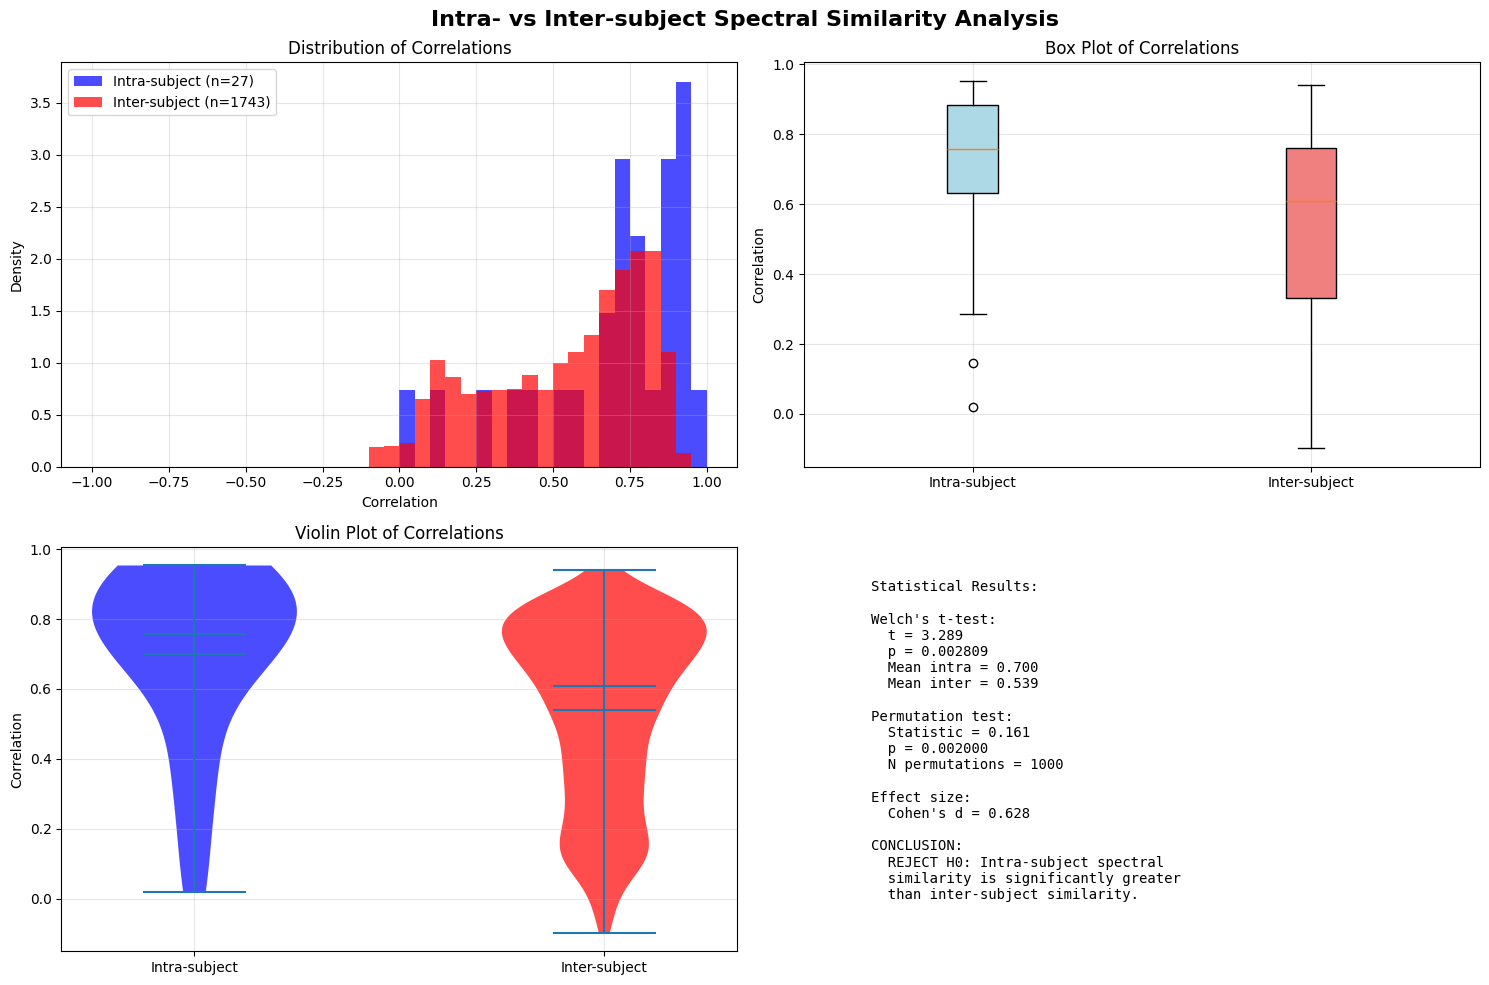


INTERPRETATION
H0: Intra-subject spectral similarity = Inter-subject spectral similarity
H1: Intra-subject spectral similarity > Inter-subject spectral similarity

Results (based on averaged trial data):
  Mean intra-subject correlation: 0.6995
  Mean inter-subject correlation: 0.5389
  Difference: 0.1606

Statistical significance:
  p-value: 0.002809 ** (p < 0.01)
  Effect size (Cohen's d): 0.628
  Effect magnitude: medium

CONCLUSION:
  REJECT H0: Spectra from the same subject are MORE SIMILAR
  than spectra from different subjects.
  This suggests individual spectral fingerprints exist.

TOPOGRAPHIC VISUALIZATION: Electrode maps
Creating topographic maps of electrode variability...

Creating topomap visualizations...
  Truncating freqs array to match spectra...
  Creating montage for 63-channel EEG system...
    Created montage with 63 channels
  Processing Delta (1-4 Hz)...
  Processing Theta (4-8 Hz)...
  Processing Alpha (8-13 Hz)...
  Processing Beta (13-30 Hz)...


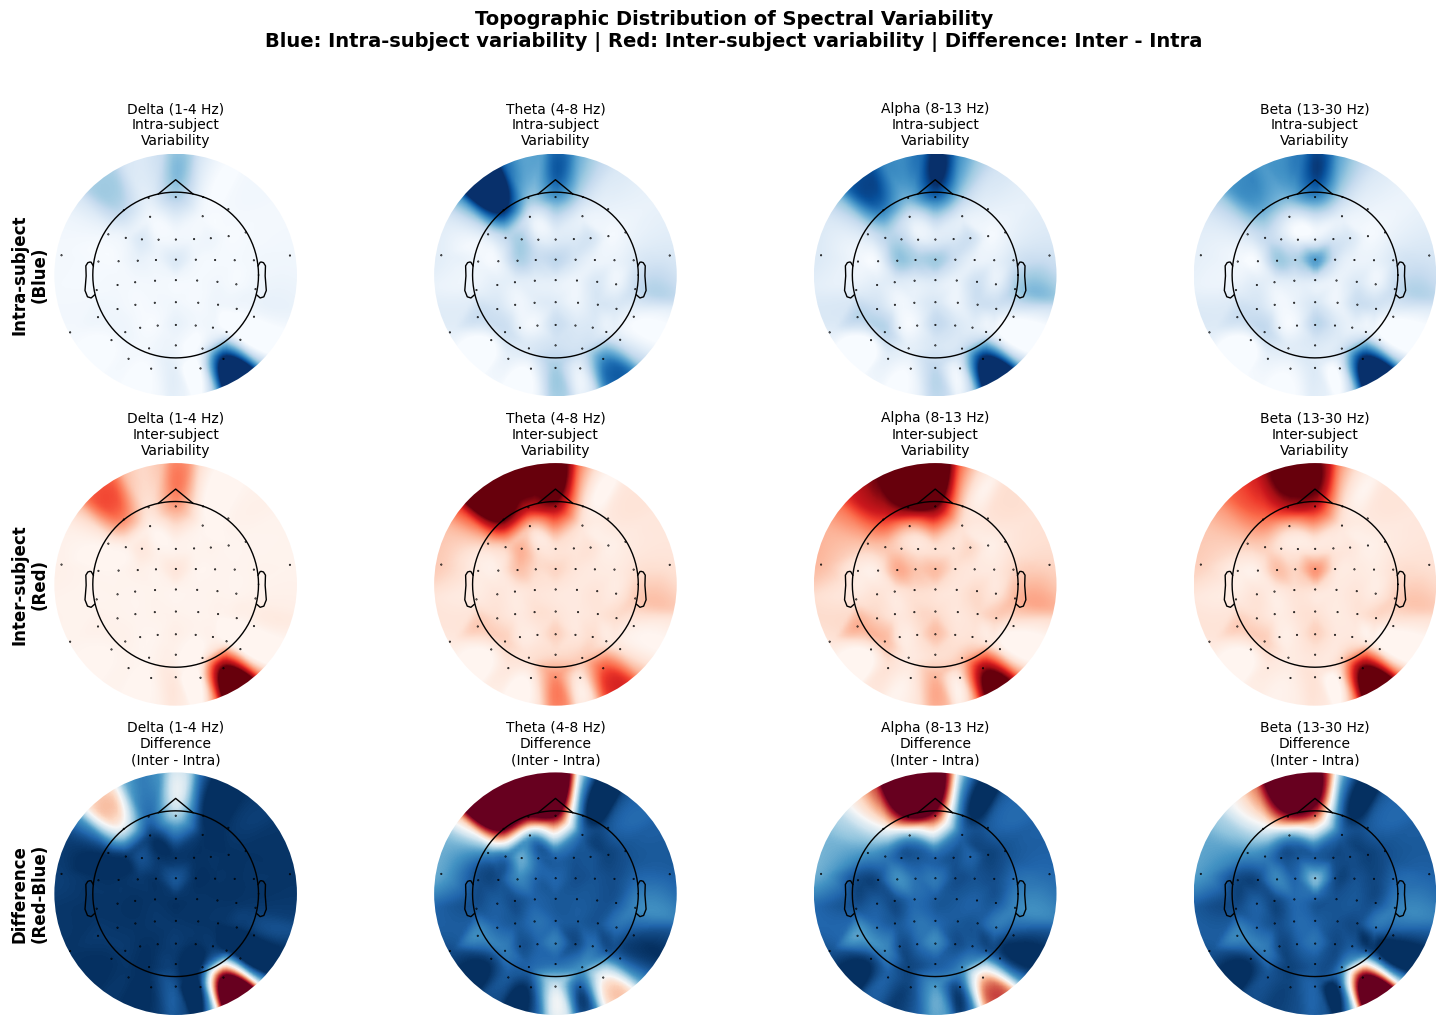


ADDITIONAL ANALYSIS: Frequency band-specific analysis


Perform frequency band analysis? (y/n):  y


Performing band analysis...
  Adjusting freqs array: 411 → 309 points

Analyzing frequency band 1-4 Hz...
  Found 22 frequency points in this band
  Performing manual permutation test (1000 permutations)...


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 11785.56it/s]


  Spectra processed: 60
  Intra correlations: n=27, mean=0.948
  Inter correlations: n=1743, mean=0.759
  T-test p-value: 0.000000 ***

Analyzing frequency band 4-7 Hz...
  Found 32 frequency points in this band
  Performing manual permutation test (1000 permutations)...


...

Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 18256.50it/s]

  Spectra processed: 60
  Intra correlations: n=27, mean=0.930
  Inter correlations: n=1743, mean=0.748
  T-test p-value: 0.000000 ***

Analyzing frequency band 14-30 Hz...
  Found 173 frequency points in this band


  Performing manual permutation test (1000 permutations)...


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 17642.99it/s]

  Spectra processed: 60
  Intra correlations: n=27, mean=0.956
  Inter correlations: n=1743, mean=0.722
  T-test p-value: 0.000000 ***


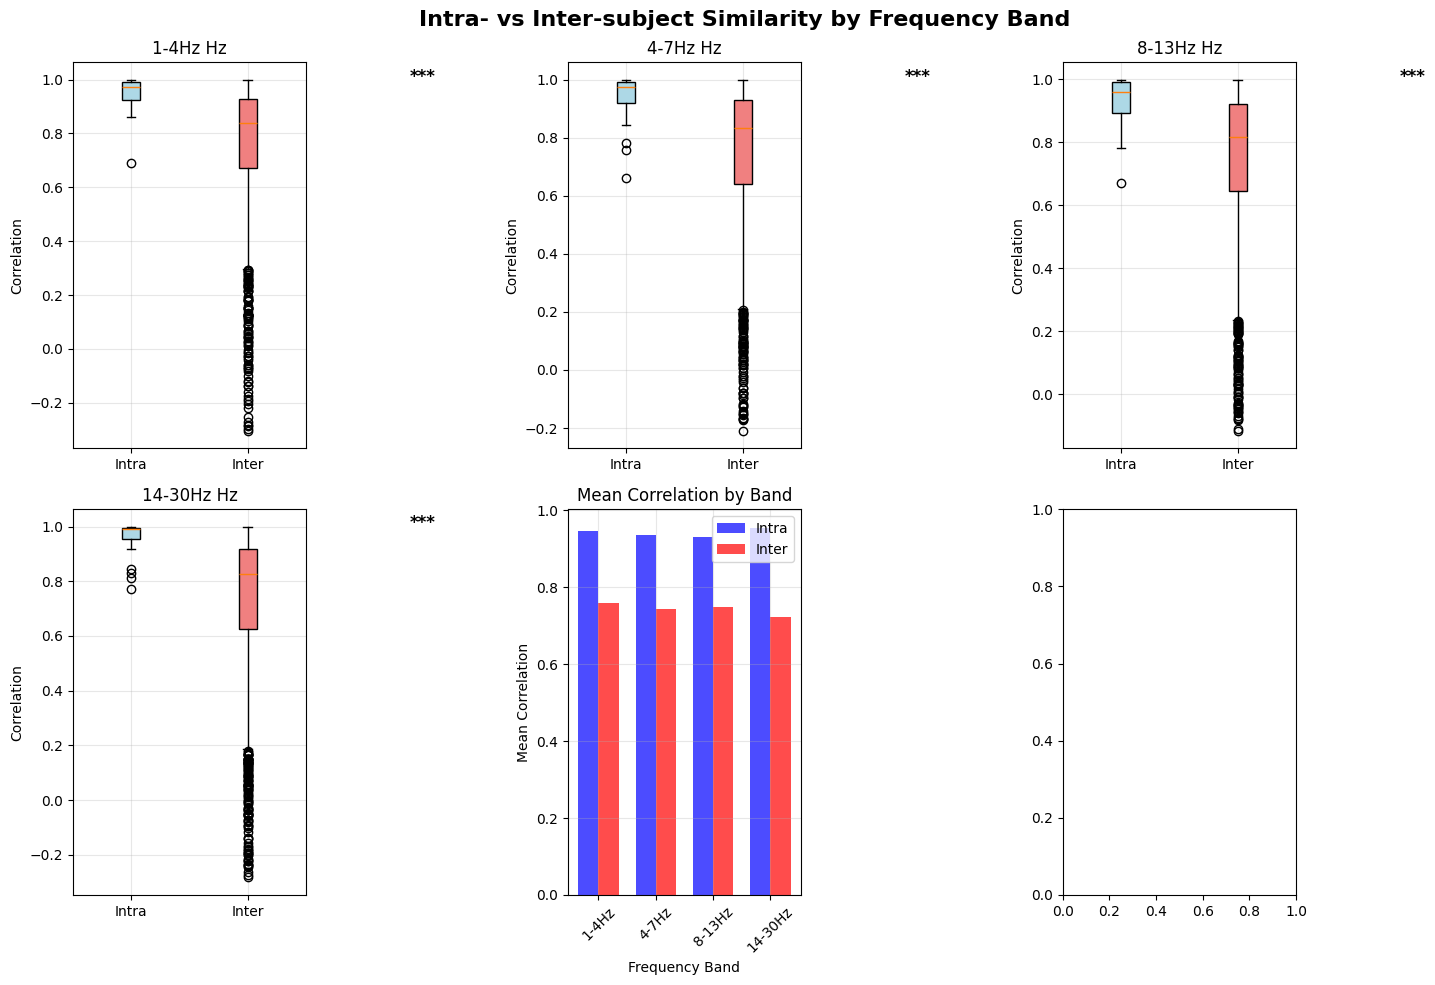


SAVING RESULTS
Correlations saved to: ../Generated/Results/subject_similarity/morlet/intra_inter_correlations_corrected.csv
  Intra-subject correlations: 27
  Inter-subject correlations: 1743
Statistical results saved to: ../Generated/Results/subject_similarity/morlet/spectral_similarity_results_corrected.csv
Data grouping info saved to: ../Generated/Results/subject_similarity/morlet/data_grouping_info.csv

ANALYSIS COMPLETED SUCCESSFULLY!

SUMMARY REPORT

Dataset (corrected grouping):
  Subjects: 33
  Trials: 60
  Intra-subject pairs: 27
  Inter-subject pairs: 1743

Key Findings:
  Mean intra-subject correlation: 0.6995
  Mean inter-subject correlation: 0.5389
  Difference: 0.1606
  p-value: 0.002809

✓ SIGNIFICANT: Subjects have individual spectral fingerprints
  (p = 0.002809)



In [13]:
# Запуск анализа
if __name__ == "__main__":
    # Отключаем предупреждения для чистоты вывода
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    warnings.filterwarnings('ignore', category=UserWarning)
    
    # Выполняем исправленный анализ
    try:
        analysis_results = main_analysis_corrected()
        
        # Вывод краткого отчета
        print("\n" + "="*70)
        print("SUMMARY REPORT")
        print("="*70)
        
        if analysis_results['results'] and 't_test' in analysis_results['results']:
            t_res = analysis_results['results']['t_test']
            
            print(f"\nDataset (corrected grouping):")
            print(f"  Subjects: {analysis_results['n_subjects']}")
            print(f"  Trials: {analysis_results['n_trials']}")
            print(f"  Intra-subject pairs: {len(analysis_results['intra_corrs'])}")
            print(f"  Inter-subject pairs: {len(analysis_results['inter_corrs'])}")
            
            print(f"\nKey Findings:")
            print(f"  Mean intra-subject correlation: {t_res['mean_intra']:.4f}")
            print(f"  Mean inter-subject correlation: {t_res['mean_inter']:.4f}")
            print(f"  Difference: {t_res['mean_intra'] - t_res['mean_inter']:.4f}")
            
            # Форматируем p-value
            if t_res['p_value'] < 1e-100:
                p_str = "< 1e-100"
            elif t_res['p_value'] < 1e-10:
                p_str = f"{t_res['p_value']:.2e}"
            else:
                p_str = f"{t_res['p_value']:.6f}"
            
            print(f"  p-value: {p_str}")
            
            if t_res['p_value'] < 0.05:
                print(f"\n✓ SIGNIFICANT: Subjects have individual spectral fingerprints")
                print(f"  (p = {p_str})")
            else:
                print(f"\n✗ NOT SIGNIFICANT: No evidence of individual spectral fingerprints")
                print(f"  (p = {p_str})")
        
        print("\n" + "="*70)
        
    except MemoryError as e:
        print(f"\n⚠️  MEMORY ERROR: {e}")
        print("Try reducing the data size or increasing memory.")
        
    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        import traceback
        traceback.print_exc()

In [ ]:
loaded = np.load('../Generated/Spectrums/exec_and_rest_morlets.npz', 
                     mmap_mode='r')
grouped_data, metadata = group_data_by_subject_trial(loaded)


Grouping data by subject and trial...


In [ ]:
from collections import defaultdict

counter = defaultdict(int)

for trial in grouped_data.values():
    for segment in trial:
        counter[segment.shape] += 1

In [ ]:
print('ну и хули тут делать, если шейпы')
print(dict(counter))
print('вот такие')